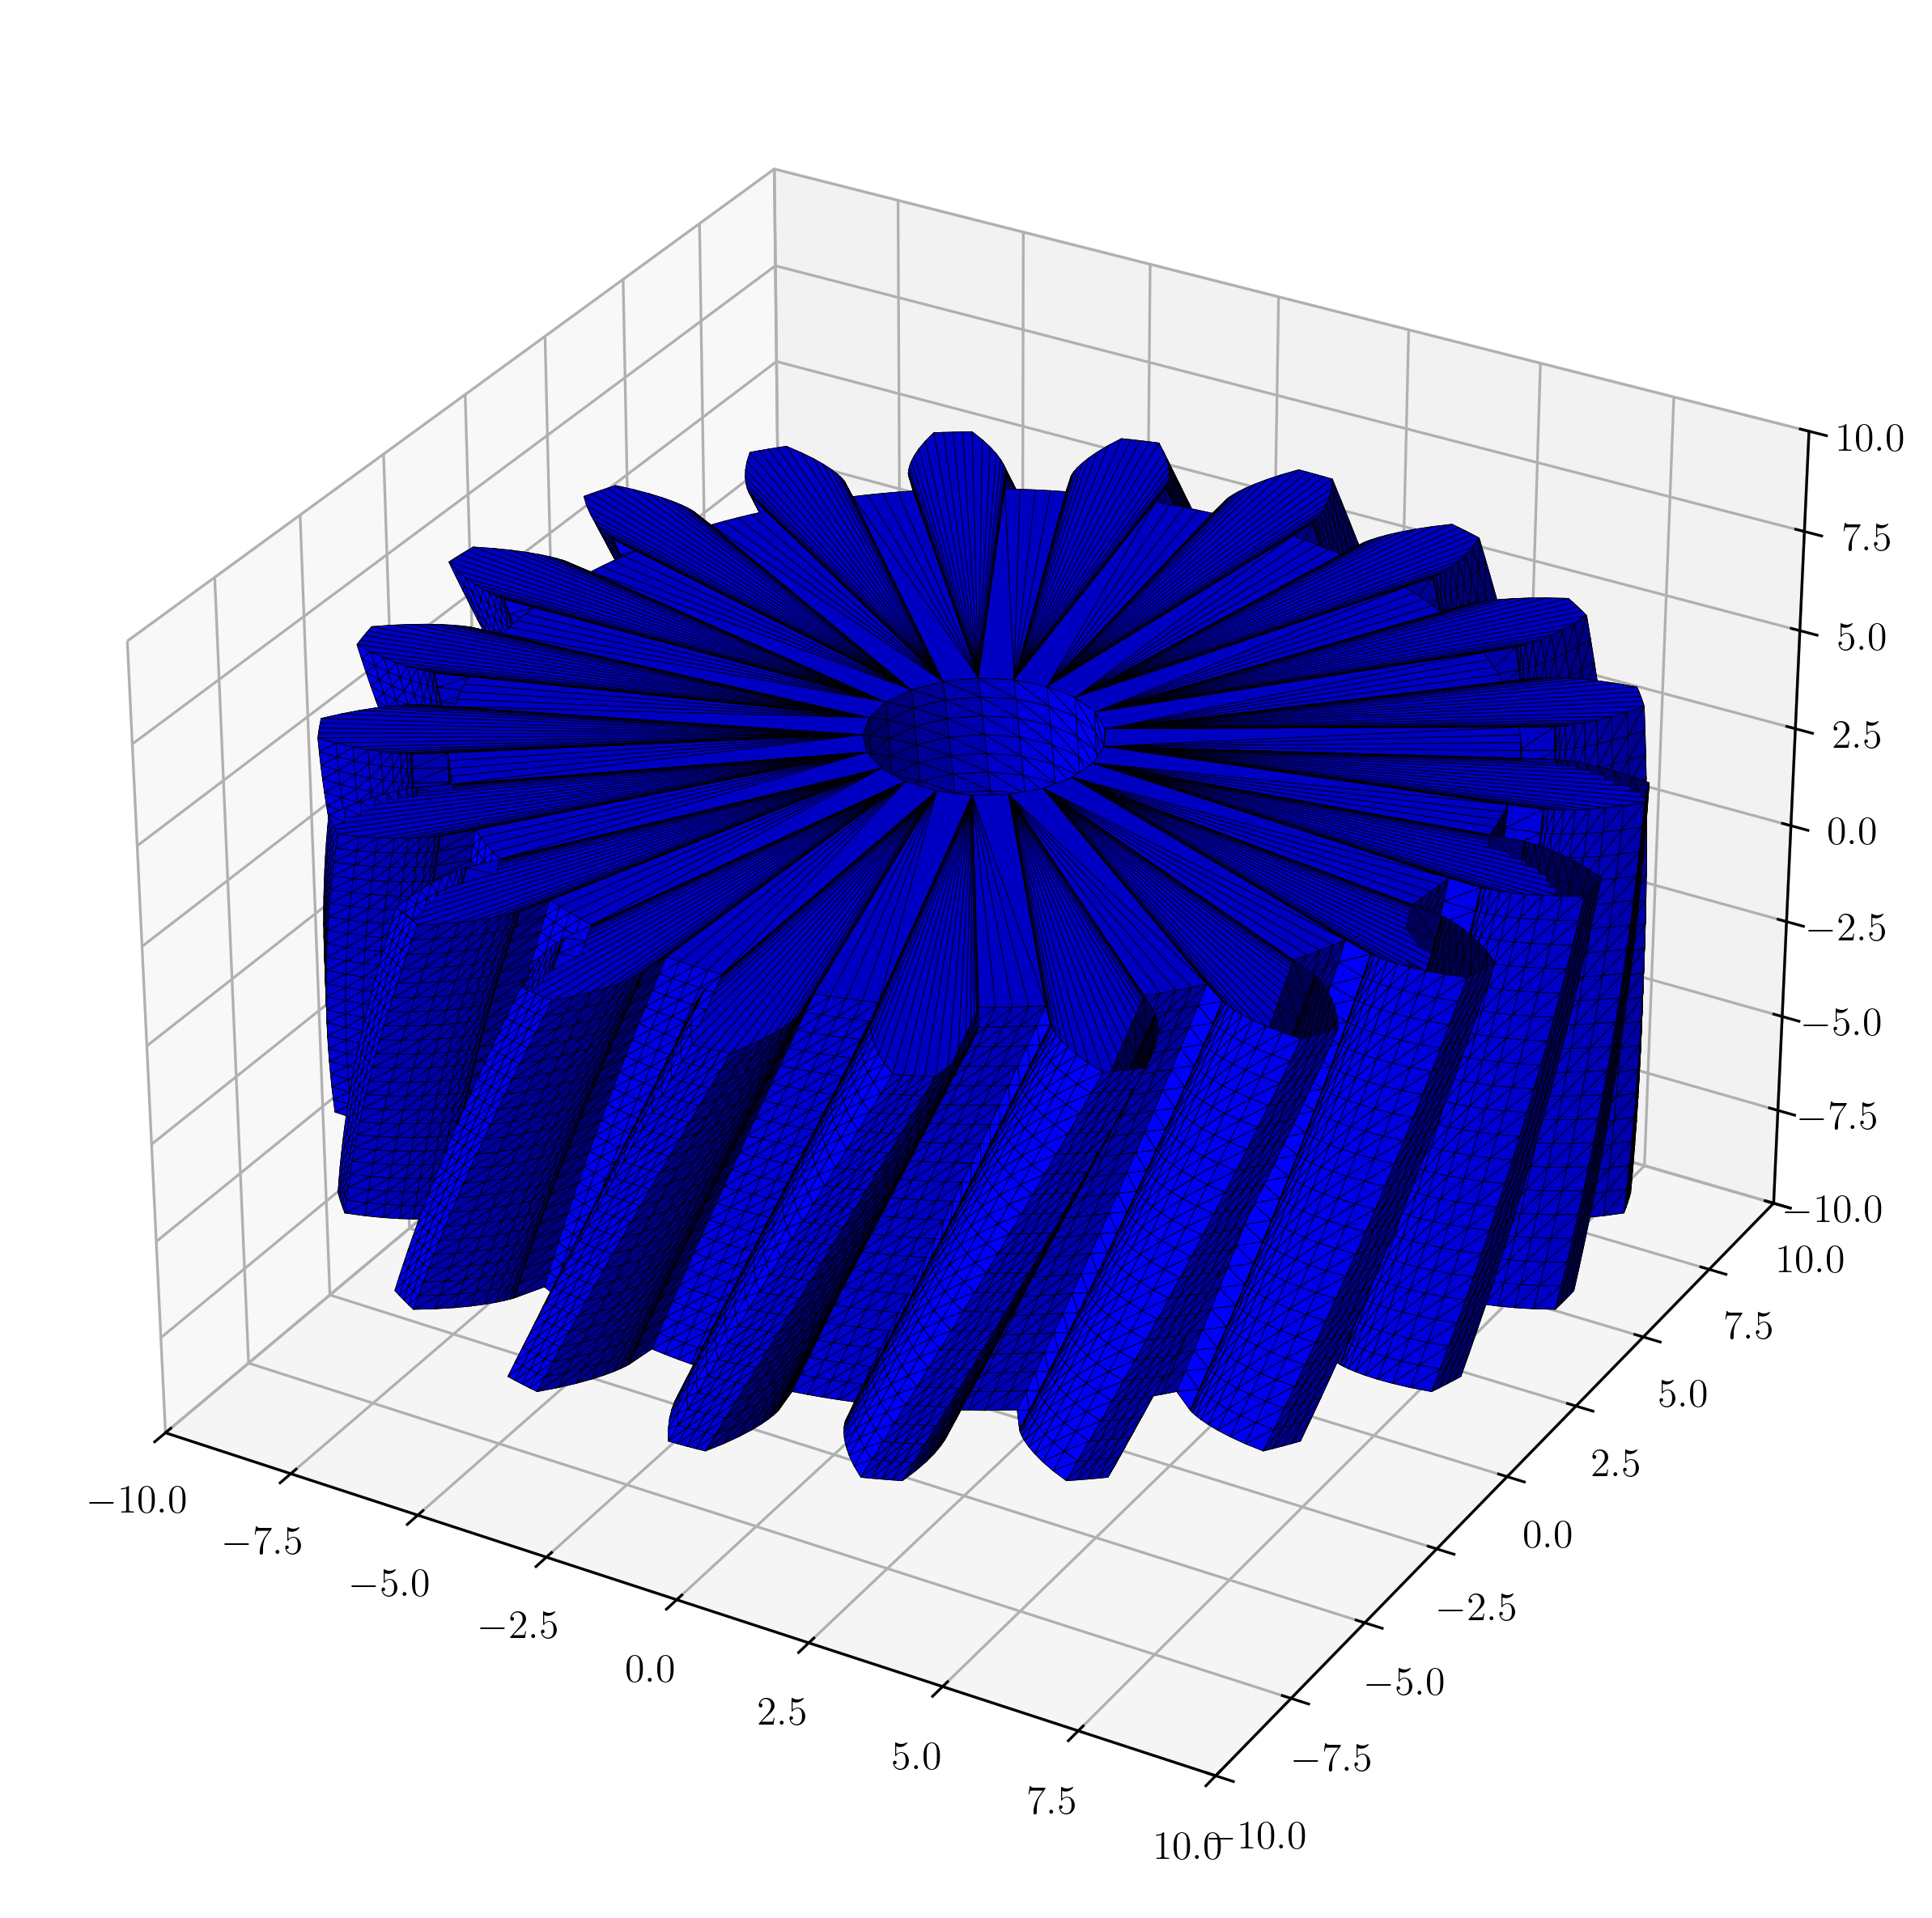

In [1]:
import matplotlib.pyplot as plt
import numpy as np

from mpl_toolkits.mplot3d import Axes3D
from stl import mesh

import rainbow.math.involute as INVOLUTE

from rainbow.procedural.gears.types import GearSpec
from rainbow.procedural.gears.generators import GearFactory

plt.rc('font', size=12)
plt.rc('text', usetex=True)
plt.rc('font', family='serif')

z = 21
m = 2 * 10 / z
spec = GearSpec(m, z, helix_angle=20, is_internal=False)

factory = GearFactory()
V, T = factory.create_involute_gear_mesh(spec, 10, subdivisions=20)

m = mesh.Mesh(np.zeros(T.shape[0], dtype=mesh.Mesh.dtype))
for i, f in enumerate(T):
    for j in range(3):
        m.vectors[i][j] = V[f[j], :]
m.save('gear.stl')

plt.figure(figsize=(10, 10), dpi=300)
ax = plt.axes(projection='3d')
ax.set_xlim(-10, 10)
ax.set_ylim(-10, 10)
ax.set_zlim(-10, 10)

ax.plot_trisurf(V[:, 0], V[:, 1], V[:, 2], triangles=T, color='blue', edgecolor='black', linewidth=0.2)

In [ ]:

plt.figure(figsize=(10, 5), dpi=300)
plt.grid(True)
plt.axis('equal')
plt.axis('off')

side_points = 10
top_points = 3
bottom_points = 3

ts = np.linspace(spec.t_min, spec.t_max, side_points)
rev_ts = -ts[::-1]

xs = []
ys = []
for idx in range(spec.z):
    theta_i = spec.theta_i[idx]
    theta_i_next = spec.theta_i[(idx + 1) % spec.z]
    if theta_i_next < theta_i:
        theta_i_next += 2 * np.pi
    
    right_root_offset = theta_i - spec.gamma_b / 2
    left_root_offset = theta_i + spec.gamma_b / 2
    
    # Right side
    right_inv_x = INVOLUTE.create_involute_x_function(spec.rb, right_root_offset)
    right_inv_y = INVOLUTE.create_involute_y_function(spec.rb, right_root_offset)
    xs.extend(right_inv_x(ts))
    ys.extend(right_inv_y(ts))
    
    # Top
    right_top_offset = theta_i - spec.gamma_a / 2
    left_top_offset = theta_i + spec.gamma_a / 2
    top_theta = np.linspace(right_top_offset, left_top_offset, top_points + 2)[1:-1]
    xs.extend(spec.ra * np.cos(top_theta))
    ys.extend(spec.ra * np.sin(top_theta))
    
    # Left side
    left_inv_x = INVOLUTE.create_involute_x_function(spec.rb, left_root_offset)
    left_inv_y = INVOLUTE.create_involute_y_function(spec.rb, left_root_offset)
    xs.extend(left_inv_x(rev_ts))
    ys.extend(left_inv_y(rev_ts))
    
    # Bottom
    if spec.rb >= spec.rd:
        bottom_theta = np.linspace(left_root_offset, left_root_offset + 2 * spec.gamma_p - spec.gamma_b, bottom_points + 2)
        xs.extend(spec.rd * np.cos(bottom_theta))
        ys.extend(spec.rd * np.sin(bottom_theta))
    else:
        bottom_start = theta_i + spec.gamma_d / 2
        bottom_end = theta_i_next - spec.gamma_d / 2
        bottom_theta = np.linspace(bottom_start, bottom_end, bottom_points + 2)[1:-1]
        xs.extend(spec.rd * np.cos(bottom_theta))
        ys.extend(spec.rd * np.sin(bottom_theta))

plt.plot(xs, ys, linewidth=0.2)
plt.plot([x + 2 * spec.rp for x in xs], ys, linewidth=0.2)

In [ ]:
points_per_tooth = 2 * side_points + top_points + ((bottom_points + 2) if spec.rb >= spec.rd else bottom_points)
total_points = spec.z * points_per_tooth

print(f'Total points: {total_points}')
print(f'Points per tooth: {points_per_tooth}')
print(len(xs))
print(len(ys))
print(len(xs) / spec.z)
print(len(xs) // spec.z)

inner_r = spec.ra + spec.m if spec.is_internal else min(spec.rd, spec.rb) - spec.m
inner_theta = np.linspace(0, 2 * np.pi, spec.z + 1)[:-1]
if spec.is_internal:
    inner_theta += np.pi / spec.z

inner_xs = inner_r * np.cos(inner_theta)
inner_ys = inner_r * np.sin(inner_theta)
xs.extend(inner_xs)
ys.extend(inner_ys)

In [ ]:
V = np.vstack((xs, ys)).T
T = []

print(total_points)
print(points_per_tooth)
print(len(V))
print(len(V) / spec.z)
print(len(V) // spec.z)

index_shift = 0
if spec.is_internal:
    index_shift = (points_per_tooth - top_points) // 2

print(f'Index shift: {index_shift}')
profile_indices = np.array([[i + j * points_per_tooth for i in range(points_per_tooth)] for j in range(spec.z)])
profile_indices = (profile_indices + index_shift) % total_points
circle_indices = np.array(range(total_points, total_points + spec.z))

for k, (ci, pi) in enumerate(zip(circle_indices, profile_indices)):
    T.append((ci, profile_indices[k-1][-1], pi[0]))
    T.append((ci, circle_indices[k-1], profile_indices[k-1][-1]))
    for i in range(points_per_tooth - 1):
        j1 = (i + 1) % points_per_tooth
        T.append((ci, pi[i], pi[j1]))

V = np.hstack((V, np.zeros((V.shape[0], 1))))
T = np.array(T)

plt.figure(figsize=(10, 10), dpi=300)
plt.grid(True)
plt.axis('equal')
plt.axis('off')

#plt.scatter(V[:, 0], V[:, 1], s=1, c='black')
plt.triplot(V[:, 0], V[:, 1], T, color='blue', linewidth=0.5)

In [ ]:
counter = 0
for i, j, k in T:
    vi = V[i]
    vj = V[j]
    vk = V[k]
    v1 = vj - vi
    v2 = vk - vi
    n = np.cross(v1, v2)
    n /= np.linalg.norm(n)
    if n[2] > 0:
        print(f'Inverted normal, triangle: {i}, {j}, {k}')
        counter += 1

print(f'Inverted normals: {counter}')
print(f'Total triangles: {len(T)}')

In [ ]:
V1 = np.copy(V)
V2 = np.copy(V1)
V2[:, 2] = 1
V = np.vstack((V1, V2))

T1 = T[:,::-1]
T2 = np.copy(T) + V1.shape[0]
T_outside = []
for i in range(total_points):
    j1 = i + V1.shape[0]
    j2 = (i + 1) % total_points
    k = ((i + 1) % total_points) + V1.shape[0]
    T_outside.append((i, k, j1))
    T_outside.append((i, j2, k))

T_inside = []
for idx in range(spec.z):
    i = idx + total_points
    j1 = i + V1.shape[0]
    j2 = (idx + 1) % spec.z + total_points
    k = ((idx + 1) % spec.z) + total_points + V1.shape[0]
    T_inside.append((i, j1, k))
    T_inside.append((i, k, j2))

# check for inverted normals
counter1 = 0
for i, j, k in T_outside:
    vi = V[i]
    vj = V[j]
    vk = V[k]
    v1 = vj - vi
    v2 = vk - vi
    n = np.cross(v1, v2)
    if np.dot(n, vi) > 0:
        print(f'Inverted normal, triangle: {i}, {j}, {k}, normal: {n}, vi: {vi}')
        counter1 += 1

# check for inverted normals
counter2 = 0
for i, j, k in T_inside:
    vi = V[i]
    vj = V[j]
    vk = V[k]
    v1 = vj - vi
    v2 = vk - vi
    n = np.cross(v1, v2)
    if np.dot(n, vi) > 0:
        print(f'Inverted normal, triangle: {i}, {j}, {k}, normal: {n}, vi: {vi}')
        counter2 += 1

print(f'Inverted normals outside: {counter1}')
print(f'Inverted normals inside: {counter2}')
print(f'Total triangles outside: {len(T_outside)}')
print(f'Total triangles inside: {len(T_inside)}')

T = np.vstack((T1, T2, T_outside, T_inside))
if spec.is_internal:
    T = T[:,::-1]

In [ ]:
plt.figure(figsize=(10, 10), dpi=300)
ax = plt.axes(projection='3d')
ax.set_xlim(-10, 10)
ax.set_ylim(-10, 10)
ax.set_zlim(-10, 10)

ax.plot_trisurf(V[:, 0], V[:, 1], V[:, 2], triangles=T, color='blue', edgecolor='black', linewidth=0.2)

In [10]:
m = mesh.Mesh(np.zeros(T.shape[0], dtype=mesh.Mesh.dtype))
for i, f in enumerate(T):
    for j in range(3):
        m.vectors[i][j] = V[f[j], :]
m.save('gear.stl')